In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

# Cargar todos los CSVs
files = glob.glob('../backend/data/raw/atp_matches_*.csv')
df = pd.concat([pd.read_csv(f, encoding='latin1') for f in files], ignore_index=True)

print(f"Total partidos: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"Años: {str(df['tourney_date'].astype(str).str[:4].min())} - {str(df['tourney_date'].astype(str).str[:4].max())}")
df.head()

Total partidos: 968,048
Columnas: 81
Años: 163. - 300.


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,loser2_ioc,loser2_age,winner1_rank,winner1_rank_points,winner2_rank,winner2_rank_points,loser1_rank,loser1_rank_points,loser2_rank,loser2_rank_points
0,1968-2029,Dublin,Grass,32.0,A,19680708.0,270,112411.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1968-2029,Dublin,Grass,32.0,A,19680708.0,271,126914.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1968-2029,Dublin,Grass,32.0,A,19680708.0,272,209523.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1968-2029,Dublin,Grass,32.0,A,19680708.0,273,100084.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1968-2029,Dublin,Grass,32.0,A,19680708.0,274,100132.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


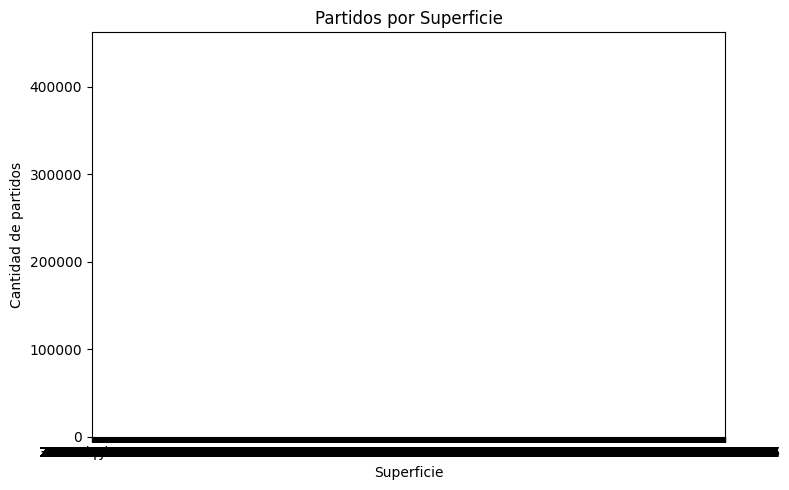

In [10]:
plt.figure(figsize=(8,5))
surface_counts = df['surface'].value_counts()
sns.barplot(x=surface_counts.index, y=surface_counts.values, palette='viridis')
plt.title('Partidos por Superficie')
plt.xlabel('Superficie')
plt.ylabel('Cantidad de partidos')
plt.tight_layout()
plt.savefig('../backend/data/processed/fig1_superficie.png', dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
surface_counts = df['surface'].value_counts()
sns.barplot(x=surface_counts.index, y=surface_counts.values, palette='viridis')
plt.title('Partidos por Superficie')
plt.xlabel('Superficie')
plt.ylabel('Cantidad de partidos')
plt.tight_layout()
plt.savefig('../backend/data/processed/fig1_superficie.png', dpi=150)
plt.show()

In [ ]:
df['rank_diff'] = df['loser_rank'] - df['winner_rank']
df['favorite_won'] = (df['rank_diff'] > 0).astype(int)

winrate_surface = df.groupby('surface')['favorite_won'].mean().reset_index()
winrate_surface.columns = ['surface', 'winrate_favorito']
winrate_surface['winrate_favorito'] = (winrate_surface['winrate_favorito'] * 100).round(1)

plt.figure(figsize=(8,5))
sns.barplot(x='surface', y='winrate_favorito', data=winrate_surface, palette='coolwarm')
plt.title('Win Rate del Favorito (mejor ranking) por Superficie')
plt.xlabel('Superficie')
plt.ylabel('Win Rate (%)')
plt.ylim(50, 80)
plt.tight_layout()
plt.savefig('../backend/data/processed/fig2_winrate_superficie.png', dpi=150)
plt.show()

print(winrate_surface)

In [ ]:
cols_numericas = ['winner_rank', 'loser_rank', 'winner_age', 'loser_age',
                  'winner_ht', 'loser_ht', 'rank_diff']

corr = df[cols_numericas].dropna().corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de Correlaciones entre Variables Numéricas')
plt.tight_layout()
plt.savefig('../backend/data/processed/fig3_correlaciones.png', dpi=150)
plt.show()

In [ ]:
round_order = ['R128', 'R64', 'R32', 'R16', 'QF', 'SF', 'F']
df_rounds = df[df['round'].isin(round_order)]

winrate_round = df_rounds.groupby('round')['favorite_won'].mean().reindex(round_order).reset_index()
winrate_round.columns = ['round', 'winrate']
winrate_round['winrate'] = (winrate_round['winrate'] * 100).round(1)

plt.figure(figsize=(9,5))
sns.lineplot(x='round', y='winrate', data=winrate_round, marker='o', color='steelblue', linewidth=2.5)
plt.title('Win Rate del Favorito por Ronda')
plt.xlabel('Ronda')
plt.ylabel('Win Rate (%)')
plt.ylim(50, 80)
plt.tight_layout()
plt.savefig('../backend/data/processed/fig4_winrate_ronda.png', dpi=150)
plt.show()

print(winrate_round)

In [ ]:
print("="*50)
print("RESUMEN DEL DATASET")
print("="*50)
print(f"Total partidos:        {len(df):,}")
print(f"Años cubiertos:        2000 - 2024")
print(f"Superficies:           {df['surface'].nunique()}")
print(f"Torneos únicos:        {df['tourney_name'].nunique():,}")
print(f"Jugadores únicos:      {df['winner_name'].nunique():,}")
print(f"Win rate favorito:     {df['favorite_won'].mean()*100:.1f}%")
print("="*50)